# Graph & manifold clustering — spectral, Leiden, consensus

Three heads that go beyond centroids, all running on the CF-tree's `M ≪ N` leaf microclusters:

- **`method="spectral"`** — a self-tuning k-NN affinity graph + normalized-Laplacian embedding
  (Ng-Jordan-Weiss). Recovers *non-convex / manifold* clusters (moons, spirals) that k-means cannot,
  and — because the eigensolve runs on the microclusters, not all `N` — it scales where
  scikit-learn's `SpectralClustering` caps out.
- **`method="leiden"`** — graph community detection (the full Leiden algorithm: local moving +
  refinement + seeded aggregation). It **discovers the community count** from the graph; no `k`
  needed. Tune granularity with `resolution` γ (or `"leiden-cpm"` for the resolution-limit-free CPM).
- **`consensus(...)`** — clusters several insertion-order permutations and votes, turning the
  CF-tree's order sensitivity into a **per-point stability score**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

import betula_cluster

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

print("betula-cluster", betula_cluster.__version__)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})


def two_spirals(n, noise=0.2, seed=0):
    """Two intertwined spirals — the classic manifold that centroid methods cannot separate."""
    rng = np.random.default_rng(seed)
    t = np.sqrt(rng.random(n)) * 1.8 * np.pi
    a = np.c_[-t * np.cos(t), t * np.sin(t)] + rng.normal(0, noise, (n, 2))
    b = np.c_[t * np.cos(t), -t * np.sin(t)] + rng.normal(0, noise, (n, 2))
    return np.vstack([a, b]), np.r_[np.zeros(n), np.ones(n)].astype(int)

betula-cluster 0.7.0


## Spectral vs k-means on manifolds

Pair spectral with a small `threshold` (many microclusters) so the affinity graph resolves the
manifold. k-means slices straight across the arms; spectral follows them.

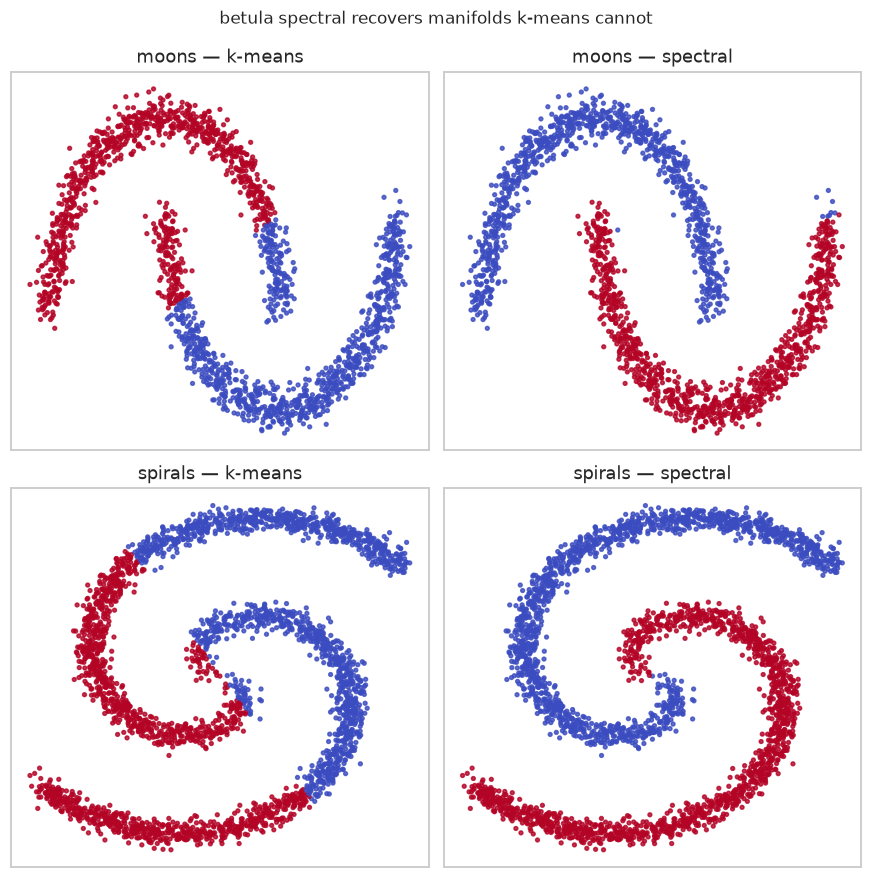

In [2]:
manifolds = {
    "moons": StandardScaler().fit_transform(make_moons(n_samples=2000, noise=0.06, random_state=0)[0]),
    "spirals": StandardScaler().fit_transform(two_spirals(1500, seed=1)[0]),
}
KW = dict(n_clusters=2, threshold=0.0, max_leaves=1500, seed=0)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for row, (name, X) in enumerate(manifolds.items()):
    km = betula_cluster.fit_predict(X, method="kmeans", **KW)
    sp = betula_cluster.fit_predict(X, method="spectral", **KW)
    for ax, labels, title in ((axes[row, 0], km, "k-means"), (axes[row, 1], sp, "spectral")):
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", s=6, alpha=0.8)
        ax.set(title=f"{name} — {title}", xticks=[], yticks=[])
fig.suptitle("betula spectral recovers manifolds k-means cannot", y=0.99)
fig.tight_layout()

## Leiden — community detection without `k`

Leiden reads the number of communities off the microcluster affinity graph. Here five blobs are
found with no `n_clusters` argument (it is ignored). Pair it with a *moderate* threshold — a very
fine graph over-splits, per modularity's resolution limit.

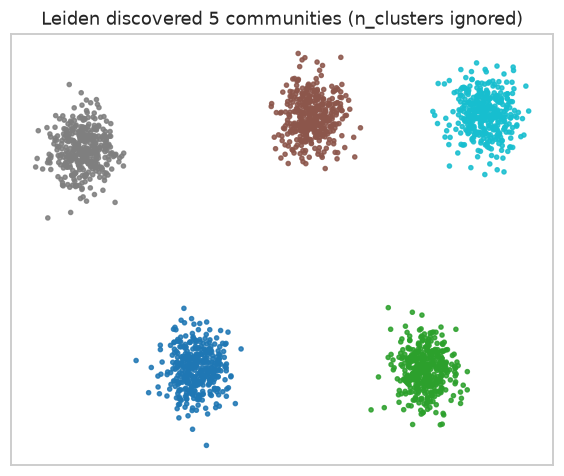

In [3]:
centers = [[0, 0], [8, 0], [4, 7], [-4, 6], [10, 7]]
Xc = np.vstack([np.random.default_rng(i).normal(c, 0.55, (400, 2)) for i, c in enumerate(centers)])
comm = betula_cluster.fit_predict(Xc, n_clusters=99, method="leiden", threshold=0.4, max_leaves=600)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(Xc[:, 0], Xc[:, 1], c=comm, cmap="tab10", s=7, alpha=0.85)
ax.set(title=f"Leiden discovered {len(set(comm))} communities (n_clusters ignored)", xticks=[], yticks=[])
fig.tight_layout()

## Consensus — a per-point stability map

On overlapping blobs, boundary points land in different clusters under different insertion orders.
`consensus` votes across permutations and reports a per-point confidence in `[0, 1]`: the dense
cores are stable (bright), the overlap seams are not (dark).

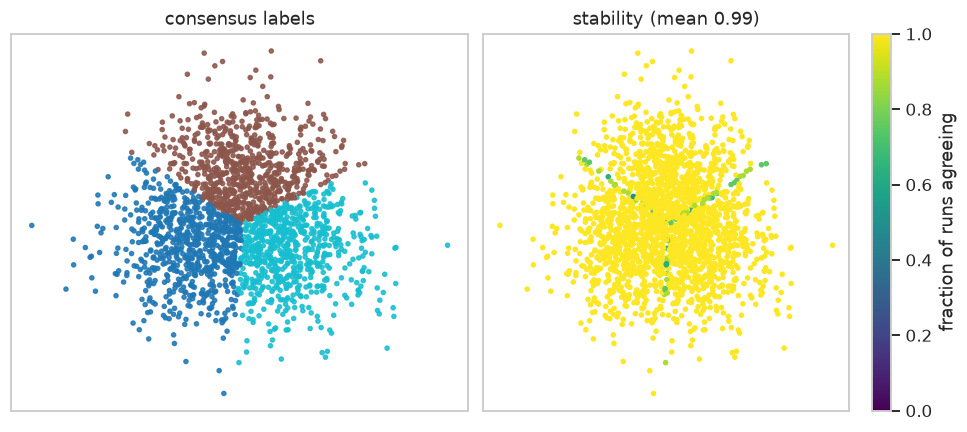

In [4]:
Xo = np.vstack([np.random.default_rng(i).normal(c, 1.6, (700, 2)) for i, c in enumerate([[0, 0], [3.2, 0], [1.6, 2.8]])])
res = betula_cluster.consensus(Xo, n_clusters=3, n_runs=8, method="kmeans", threshold=0.1, n_jobs=-1)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 4))
ax0.scatter(Xo[:, 0], Xo[:, 1], c=res.labels, cmap="tab10", s=7, alpha=0.85)
ax0.set(title="consensus labels", xticks=[], yticks=[])
sc = ax1.scatter(Xo[:, 0], Xo[:, 1], c=res.confidence, cmap="viridis", s=7, vmin=0, vmax=1)
ax1.set(title=f"stability (mean {res.mean_confidence:.2f})", xticks=[], yticks=[])
fig.colorbar(sc, ax=ax1, label="fraction of runs agreeing")
fig.tight_layout()

**Takeaways.** Spectral for manifolds, Leiden for communities (auto-count), consensus for a
calibrated per-point confidence — all on the compressed CF microclusters, so all scale with the
number of leaves rather than `N`. See the [Usage guide](../docs/USAGE.md) and
[`bench/spectral_nonconvex.py`](../bench/spectral_nonconvex.py) for the spectral-vs-sklearn timings.